In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
DATA_PATH="../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [8]:
df=pd.read_csv(DATA_PATH)

In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [11]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

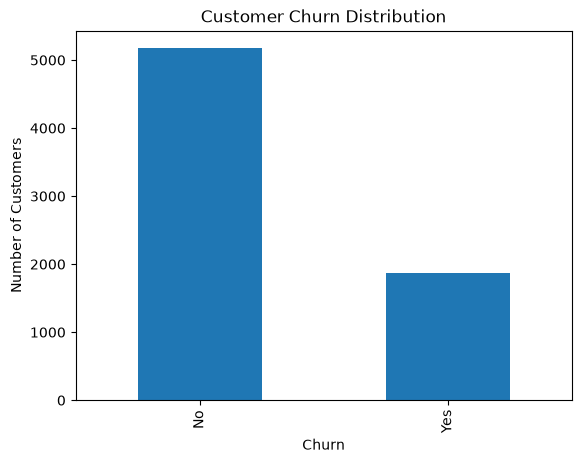

In [16]:
df['Churn'].value_counts().plot(kind='bar')

plt.title('Customer Churn Distribution')
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [26]:
pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


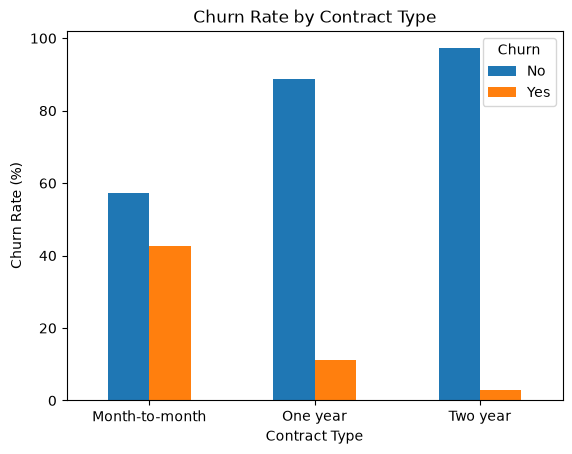

In [31]:
contract_churn=pd.crosstab(df['Contract'],df['Churn'],normalize='index')*100


contract_churn.plot(kind='bar')

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=0)
plt.legend(title='Churn')
plt.show()

In [34]:
df.groupby('Churn')['tenure'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


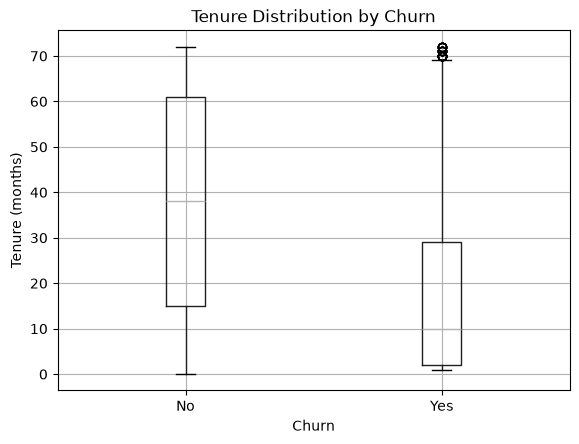

In [39]:
df.boxplot(column='tenure',by='Churn')

plt.title('Tenure Distribution by Churn')
plt.suptitle("")

plt.xlabel("Churn")
plt.ylabel("Tenure (months)")
plt.show()

In [41]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


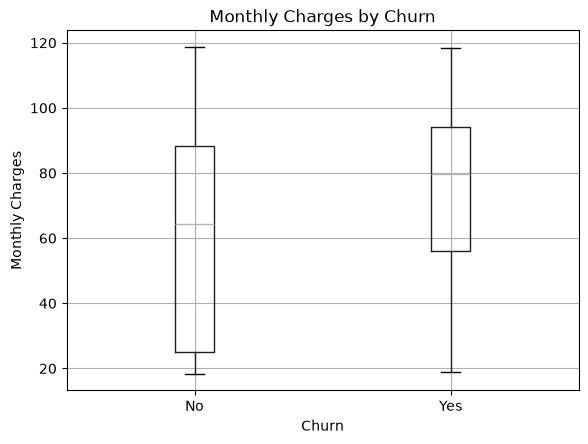

In [42]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")

plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [47]:
internet_churn=pd.crosstab(df['InternetService'],df['Churn'],normalize='index')*100
internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


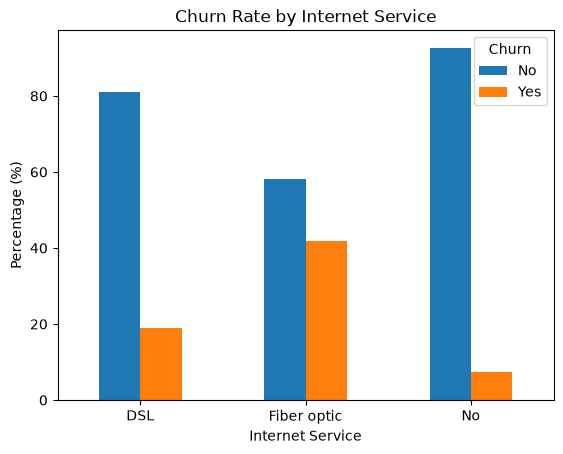

In [49]:
internet_churn.plot(kind='bar')

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()

In [52]:
tech_support_churn=pd.crosstab(df['TechSupport'],df['Churn'],normalize='index')*100
tech_support_churn

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


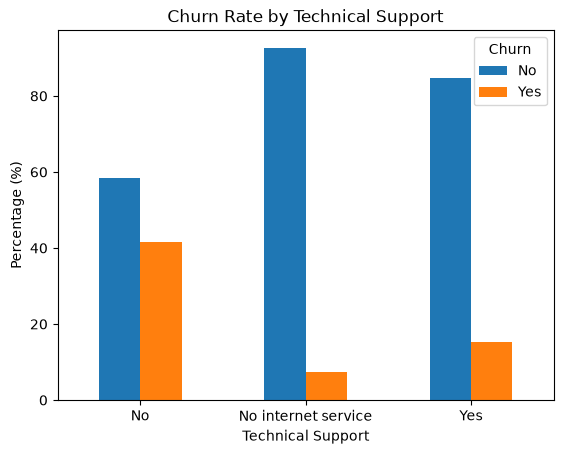

In [54]:
tech_support_churn.plot(kind='bar')

plt.title("Churn Rate by Technical Support")
plt.xlabel("Technical Support")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)
plt.show()

In [55]:
payment_churn=pd.crosstab(df['PaymentMethod'],df['Churn'],normalize='index')*100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


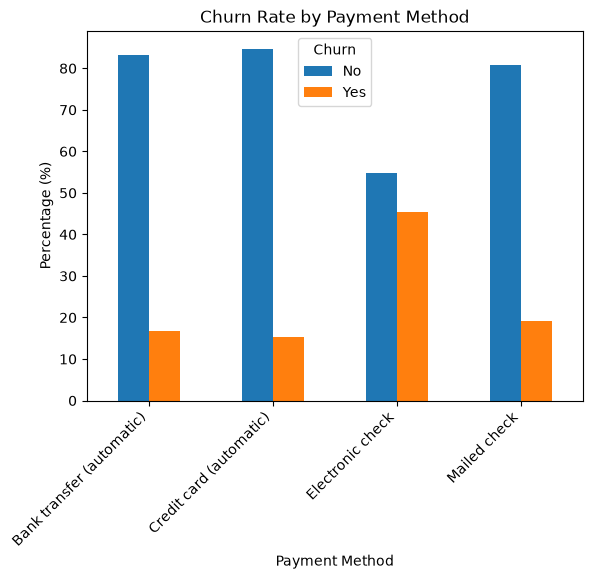

In [60]:
payment_churn.plot(kind='bar')

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=45,ha='right')

plt.show()

In [61]:
def churn_rate_by_column(df,column):
    result=pd.crosstab(df[column],df['Churn'],normalize='index')*100
    return result
    

In [62]:
churn_rate_by_column(df,'InternetService')

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [63]:
churn_rate_by_column(df,'StreamingTV')

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


In [64]:
df['TotalCharges'].dtype

<StringDtype(storage='python', na_value=nan)>

In [65]:
df['TotalCharges'].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: str

In [68]:
df['TotalCharges'].unique()[:40]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9',   '39.65',
  '202.25',   '20.15',  '3505.1',  '2970.3',  '1530.6', '4749.15',    '30.2',
 '6369.45',  '1093.1', '6766.95',  '181.65', '1874.45',    '20.2',   '45.25',
  '7251.7',   '316.9',  '3548.3', '3549.25',  '1105.4']
Length: 40, dtype: str

In [69]:
df['customerID'].duplicated().sum()

np.int64(0)